# Customer Churn — Data Quality Audit & Exploratory Analysis

**Dataset:** `customer_churn_sample.csv` (15 customer records, 11 columns)

This notebook does four things, in order:

1. **Profile** the raw data — types, missing values, duplicates, outliers.
2. **Clean** the data, with every assumption and validation check written down as I make it.
3. **Summarize** the cleaned data and look at the distributions that matter for churn.
4. **Conclude** with the initial patterns I see and what I'd want to check next with more data.


## 1.Load The Data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

df_raw = pd.read_csv('customer_churn_sample.csv')
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head(15)


Shape: 15 rows x 11 columns


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes
5,CUST-1006,Male,31,18,Basic,49.99,899.82,One Year,2,UPI,No
6,CUST-1007,Female,23,3,Basic,49.99,149.97,Month-to-Month,6,Credit Card,Yes
7,CUST-1008,Male,60,48,Enterprise,149.99,7199.52,Two Year,1,Bank Transfer,No
8,CUST-1009,Female,38,15,Pro,79.99,1199.85,One Year,2,Credit Card,No
9,CUST-1010,Male,27,4,Basic,49.99,199.96,Month-to-Month,4,UPI,Yes


## 2.Profiling
2.1 Data types
Checking that every column's dtype matches what it should logically be (IDs and categories as strings/objects, counts and money as numbers).

In [9]:
df_raw.dtypes.to_frame(name='dtype')

,dtype
CustomerID,object
Gender,object
Age,int64
TenureMonths,int64
SubscriptionType,object
MonthlyCharges,float64
TotalCharges,float64
ContractType,object
SupportTickets,int64
PaymentMethod,object


Observation: types look correct on load — Age, TenureMonths, and SupportTickets are integers; MonthlyCharges and TotalCharges are floats; everything else is text. No coercion needed.

2.2 Missing values

In [13]:
missing = df_raw.isnull().sum().to_frame(name='missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df_raw) * 100).round(1)
missing

,missing_count,missing_pct
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
TenureMonths,0,0.0
SubscriptionType,0,0.0
MonthlyCharges,0,0.0
TotalCharges,0,0.0
ContractType,0,0.0
SupportTickets,0,0.0
PaymentMethod,0,0.0


Observation: zero missing values in any column. Nothing to impute or drop for this dataset.

2.3 Duplicates

In [17]:
full_row_dupes = df_raw.duplicated().sum()
id_dupes = df_raw['CustomerID'].duplicated().sum()
print(f"Fully duplicated rows: {full_row_dupes}")
print(f"Duplicate CustomerIDs: {id_dupes}")

Fully duplicated rows: 0
Duplicate CustomerIDs: 0


Observation: no duplicate rows and no duplicate CustomerID values — each record is a unique customer.

2.4 Categorical value consistency

In [21]:
cat_cols = ['Gender', 'SubscriptionType', 'ContractType', 'PaymentMethod', 'Churn']
for c in cat_cols:
    print(f"{c}: {sorted(df_raw[c].unique().tolist())}")

Gender: ['Female', 'Male']
SubscriptionType: ['Basic', 'Enterprise', 'Pro']
ContractType: ['Month-to-Month', 'One Year', 'Two Year']
PaymentMethod: ['Bank Transfer', 'Credit Card', 'Debit Card', 'UPI']
Churn: ['No', 'Yes']


Observation: every categorical column has a small, clean set of values with consistent casing and no leading/trailing whitespace. Churn is a clean binary Yes/No.

2.5 Logical / cross-field consistency

In [25]:
expected_total = (df_raw['MonthlyCharges'] * df_raw['TenureMonths']).round(2)
mismatch = (df_raw['TotalCharges'] - expected_total).abs() > 0.01
print(f"Rows where TotalCharges != MonthlyCharges x TenureMonths: {mismatch.sum()}")
df_raw.loc[mismatch, ['CustomerID', 'MonthlyCharges', 'TenureMonths', 'TotalCharges']]

Rows where TotalCharges != MonthlyCharges x TenureMonths: 0


,CustomerID,MonthlyCharges,TenureMonths,TotalCharges


Observation: all 15 rows reconcile exactly — TotalCharges is internally consistent with the other two fields, with no rounding drift.

2.6 Range checks and outliers

* Range/sanity check — do values fall inside a plausible business range (e.g. Age between 18 and 100, no negative charges or tenures)?
* Statistical outliers — the standard IQR rule (any point more than 1.5x the interquartile range beyond Q1/Q3).

In [29]:
numeric_cols = ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportTickets']

# Range/sanity checks
range_checks = {
    'Age': (df_raw['Age'].between(18, 100)).all(),
    'TenureMonths': (df_raw['TenureMonths'] >= 0).all(),
    'MonthlyCharges': (df_raw['MonthlyCharges'] > 0).all(),
    'TotalCharges': (df_raw['TotalCharges'] >= 0).all(),
    'SupportTickets': (df_raw['SupportTickets'] >= 0).all(),
}
print("Range checks (True = passes):")
for k, v in range_checks.items():
    print(f"  {k}: {v}")

print()
print("IQR outlier check:")
for c in numeric_cols:
    q1, q3 = df_raw[c].quantile(0.25), df_raw[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_raw[c] < lo) | (df_raw[c] > hi)).sum()
    print(f"  {c}: bounds=({lo:.2f}, {hi:.2f})  outliers={n_out}")

Range checks (True = passes):
  Age: True
  TenureMonths: True
  MonthlyCharges: True
  TotalCharges: True
  SupportTickets: True

IQR outlier check:
  Age: bounds=(4.50, 72.50)  outliers=0
  TenureMonths: bounds=(-23.00, 57.00)  outliers=0
  MonthlyCharges: bounds=(-47.51, 212.49)  outliers=0
  TotalCharges: bounds=(-3689.82, 7349.46)  outliers=0
  SupportTickets: bounds=(-3.50, 8.50)  outliers=0


## cleaning

In [32]:
df = df_raw.copy()

# Explicit dtype assertions as a validation gate (would raise if violated)
assert df['CustomerID'].dtype == object or str(df['CustomerID'].dtype).startswith('str'), "CustomerID should be text"
assert df[['Age', 'TenureMonths', 'SupportTickets']].select_dtypes(include='number').shape[1] == 3
assert df.isnull().sum().sum() == 0, "Unexpected missing values after cleaning"
assert df.duplicated().sum() == 0, "Unexpected duplicate rows after cleaning"
assert set(df['Churn'].unique()) == {'Yes', 'No'}, "Churn should be binary Yes/No"
assert ((df['TotalCharges'] - (df['MonthlyCharges'] * df['TenureMonths']).round(2)).abs() <= 0.01).all(), \
    "TotalCharges should reconcile with MonthlyCharges x TenureMonths"

print("All validation checks passed.")
print(f"Cleaned dataset: {df.shape[0]} rows x {df.shape[1]} columns (unchanged from raw)")

df.to_csv('customer_churn_cleaned.csv', index=False)
print("Saved: customer_churn_cleaned.csv")

All validation checks passed.
Cleaned dataset: 15 rows x 11 columns (unchanged from raw)
Saved: customer_churn_cleaned.csv


4. Summary statistics

In [35]:
df[numeric_cols].describe().round(2)

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.00,15.00,15.00,15.00,15.00
mean,39.07,18.80,84.66,2088.48,2.53
std,11.39,14.33,42.74,2407.37,1.92
min,23.00,2.00,49.99,99.98,0.00
25%,30.00,7.00,49.99,449.91,1.00
50%,38.00,15.00,79.99,1099.78,2.00
75%,47.00,27.00,114.99,3209.73,4.00
max,60.00,48.00,149.99,7199.52,6.00


In [37]:
cat_summary = pd.DataFrame({
    c: df[c].value_counts() for c in ['Gender', 'SubscriptionType', 'ContractType', 'PaymentMethod', 'Churn']
}).fillna(0).astype(int)
cat_summary

,Gender,SubscriptionType,ContractType,PaymentMethod,Churn
Bank Transfer,0,0,0,3,0
Basic,0,7,0,0,0
Credit Card,0,0,0,6,0
Debit Card,0,0,0,2,0
Enterprise,0,4,0,0,0
Female,8,0,0,0,0
Male,7,0,0,0,0
Month-to-Month,0,0,7,0,0
No,0,0,0,0,8
One Year,0,0,4,0,0


Headline numbers:

Overall churn rate: 47% (7 of 15 customers churned).
Average tenure: 18.8 months, but tenure ranges widely (2 to 48 months).
Average monthly charge: $84.66, driven by the three-tier plan structure (Basic  
49.99
/
P
r
o
 79.99 / Enterprise $149.99).

5. Distributions and initial patterns

5.1 Churn rate overall

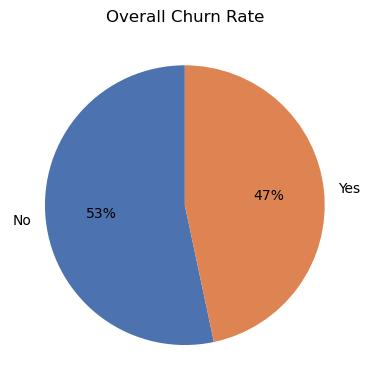

In [42]:
churn_counts = df['Churn'].value_counts()
fig, ax = plt.subplots(figsize=(4, 4))
colors = ['#4C72B0', '#DD8452']
ax.pie(churn_counts, labels=churn_counts.index, autopct='%1.0f%%', colors=colors, startangle=90)
ax.set_title('Overall Churn Rate')
plt.tight_layout()
plt.show()

5.2 Churn rate by contract type

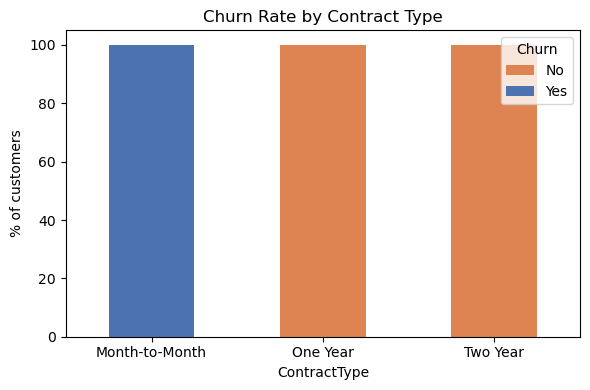

In [45]:
churn_by_contract = pd.crosstab(df['ContractType'], df['Churn'], normalize='index') * 100
churn_by_contract = churn_by_contract.reindex(['Month-to-Month', 'One Year', 'Two Year'])
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract.plot(kind='bar', stacked=True, ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_ylabel('% of customers')
ax.set_title('Churn Rate by Contract Type')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5.3 Churn rate by subscription tier

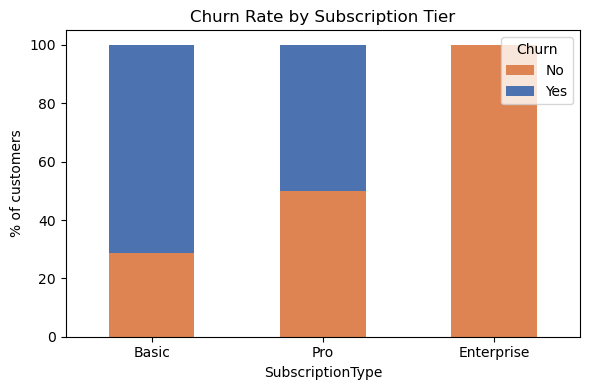

In [48]:
churn_by_sub = pd.crosstab(df['SubscriptionType'], df['Churn'], normalize='index') * 100
churn_by_sub = churn_by_sub.reindex(['Basic', 'Pro', 'Enterprise'])
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_sub.plot(kind='bar', stacked=True, ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_ylabel('% of customers')
ax.set_title('Churn Rate by Subscription Tier')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5.4 Tenure distribution, split by churn

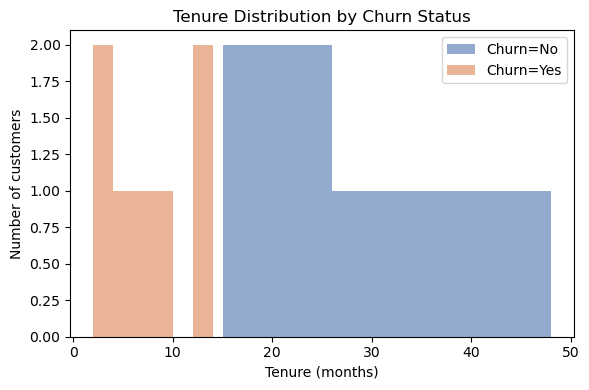

In [51]:
fig, ax = plt.subplots(figsize=(6, 4))
for status, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
    subset = df[df['Churn'] == status]['TenureMonths']
    ax.hist(subset, bins=6, alpha=0.6, label=f'Churn={status}', color=color)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of customers')
ax.set_title('Tenure Distribution by Churn Status')
ax.legend()
plt.tight_layout()
plt.show()

5.5 Support tickets vs churn

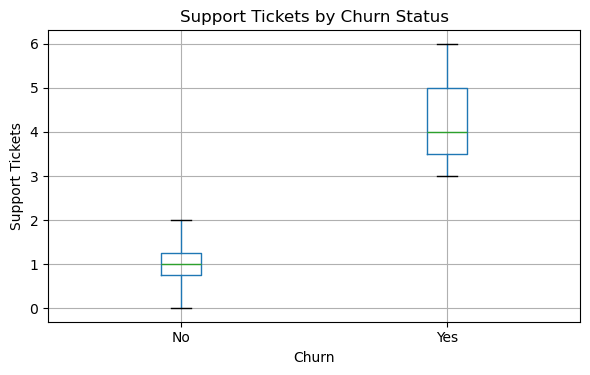

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column='SupportTickets', by='Churn', ax=ax)
ax.set_ylabel('Support Tickets')
ax.set_title('Support Tickets by Churn Status')
plt.suptitle('')
plt.tight_layout()
plt.show()

5.6 Correlation between numeric fields

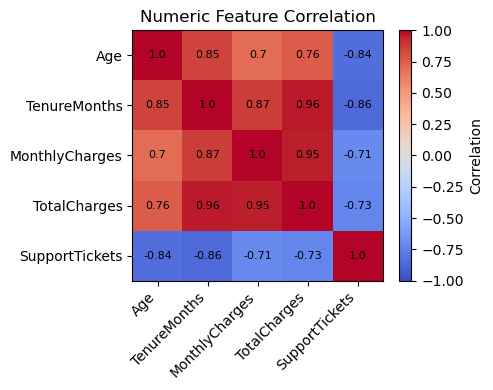

In [57]:
corr = df[numeric_cols].corr(numeric_only=True).round(2)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i, j], ha='center', va='center', color='black', fontsize=8)
fig.colorbar(im, label='Correlation')
ax.set_title('Numeric Feature Correlation')
plt.tight_layout()
plt.show()

6. Conclusions
Data quality: the dataset is clean — no missing values, no duplicates, consistent categories, and every derived field (TotalCharges) reconciles exactly with its components. No rows needed to be dropped, imputed, or corrected; the work here was verification and documentation of assumptions rather than active cleaning.

Initial patterns (descriptive only — 15 rows is too small to treat any of this as statistically significant, see caveat below):

Churn concentrates heavily in Month-to-Month contracts and the Basic tier; One Year and Two Year contracts, and the Pro/Enterprise tiers, show little to no churn in this sample.
Churned customers have noticeably shorter tenure and more support tickets than retained customers — both consistent with an intuitive "early, frustrated customers leave" story.
MonthlyCharges and TotalCharges are highly correlated with each other and with TenureMonths by construction, since TotalCharges = MonthlyCharges x TenureMonths, so any downstream model should treat these as one signal rather than three independent ones.